# Leviathan Egg Demo Walkthrough (v1 + v2)

This notebook is a visual-first walkthrough for colleagues/students.

It covers two packs:
- `demo`: lightweight single-seed scenarios
- `demo_v2`: stronger-separation scenarios with **3-seed ribbons**

Use this notebook to understand both *what the model does* and *why the plots look the way they do*.

## Under-The-Hood Pipeline

The demo uses the same harness as research runs:
- Config loading/validation: `src/leviathan_egg/config.py`
- Runner entrypoint: `src/leviathan_egg/cli.py` (`run_simulation`)
- World dynamics: `src/leviathan_egg/world.py`
- Metrics emission: `src/leviathan_egg/metrics.py`
- Demo driver: `scripts/demo_visual_quickstart.py`

No notebook-only dynamics are used.

## Model Card (ABM Under The Hood)

**Entities**
- Agent `a`: (`patch_id`, `group_id`, `prestige`, `competence`)
- Group `g`: (`members`, `authority_on`, `leader_id`, `patch_id`)
- Patch `p`: container of agents/groups; Phase 3 uses multiple patches.

**State Variables (per time step `t`)**
- Micro: group composition and leadership (`authority_on`, `leader_id`)
- Meso: group sizes and movement between groups (fission/fusion inside a patch)
- Macro: `frac_hier` globally and `frac_hier_patch_p` per patch
- Synchrony outputs (multi-patch): order, lock, mean abs lag, anti-phase fraction

**Exogenous vs Endogenous**
- Exogenous drivers: seasonal `festival(t,p)`, `crisis(t,p)`, plus derived seasonal terms from config (`aggregation_benefit`, `coordination_cost`, `hierarchy_rent`)
- Endogenous dynamics: authority adoption, leader emergence, agent movement, prestige updates, and resulting `frac_hier`
- Inter-patch coupling (Phase 3): endogenous cross-patch feedback term added to local authority pressure when enabled

**Update Order per Step (`world.step`)**
1. Compute seasonal terms per patch
2. Apply inter-patch coupling bias to seasonal authority pressure
3. Per patch: recompute authority/leader states
4. Per patch: movement step (stay/move/split via utility comparison)
5. Per patch: prestige update
6. Cleanup empty groups, then append patch hierarchy history


## Minimal Dynamics (Equations + Pseudocode)

### 1) Seasonal forcing (from `seasons.py`)
Let `theta_p(t) = 2π (t / T + phase_offset_p)` and `base_p(t) = 0.5 (1 + sin(theta_p(t)))`.

- `aggregation_benefit_p(t) = 1 + a_agg * base_p(t)`
- `coordination_cost_p(t) = 1 + a_coord * (1 - base_p(t))`
- `hierarchy_rent_p(t) = 1 + sign_authority * a_rent * base_p(t)`
- `crisis_p(t) = a_crisis * (1 - base_p(t))`
- `festival_p(t) = a_festival * pulse(theta_p(t))`

### 2) Local authority pressure + adoption (from `world.py`)
For group `g` in patch `p` with size `n_g`:

- `kappa_g(t) = coordination_cost_p(t) * n_g^alpha + (crisis_p(t) + coupling_bias_p(t)) * n_g`
- `P(authority_on_g = 1) = sigmoid(beta * (kappa_g(t) - theta_auth))`

where `alpha = cost_exponent`, `beta = authority_steepness`, `theta_auth = authority_threshold`.

### 3) Coupling term (exact implemented form)
With lagged patch hierarchy `x_p(t) = frac_hier_patch_p(t-lag_steps)`:

- `influence_p = mean_q( x_q(t) - x_p(t) )` over neighbors `q` (mean-field or topology neighbors)
- `signed_p = sign * strength * influence_p`
- `coupling_bias_p(t) = clip(max_bias * signed_p, -max_bias, +max_bias)`

(`max_bias = 0.25` in current implementation)

### 4) Movement and prestige (high level)
- Sample agents in each patch and compare utility of `stay` vs `move` vs `split`
- Utility includes aggregation benefit, coordination cost, and hierarchy rents/taxes
- Prestige is updated with decay + noise + festival bonus for leaders

### 5) Observable hierarchy fraction
- `frac_hier_patch_p(t) = (agents in authority_on groups in patch p) / (agents in patch p)`
- Global `frac_hier(t)` is the same ratio over all patches

### Pseudocode
```text
for t in 1..T:
  season[p] <- seasonal_terms(t, p)
  season[p].coupling_bias <- coupling_from_lagged_patch_hierarchy(...)
  for each patch p:
    recompute_authority_and_leaders(p, season[p])
    movement_step(p, season[p])
    prestige_update(p, season[p])
  cleanup_groups()
  record_patch_hierarchy_history()
  log_metrics()
```


## Metrics and Classifier Logic (v1 vs v2)

### Synchrony metrics (from `metrics.py`)
For patches `p = 1..P` with `x_p(t) = frac_hier_patch_p(t)`:

1. **Order parameter**
   - Map `x_p` to phase: `phi_p = 2π x_p`
   - `R = | (1/P) Σ_p exp(i phi_p) |`
   - Larger `R` means tighter phase concentration.

2. **Phase-lock fraction**
   - For each pair `(p,q)`, circular distance `d(phi_p, phi_q)`
   - Locked if `d <= 2π * 0.15`
   - Lock fraction = share of locked pairs.

3. **Mean absolute phase lag**
   - From pairwise cross-correlation on recent windows
   - Best lag constrained to `|lag| <= seasonal_period/4`
   - Metric is mean of `|best_lag|` across pairs.

4. **Anti-phase fraction**
   - Pairwise zero-lag correlation on centered histories
   - Pair marked anti-phase if corr `<= -0.2`
   - Metric is anti-phase pair share.

### Classifier decision logic used in Phase 3 analysis

Let `(R, L, G, A)` denote `(order, lock, lag, anti-phase)` means per run.

- **v1 (strict lag-gated)**
  - `synchrony` if `R >= R_hi AND L >= L_hi AND G <= G_hi`
  - `desynchrony` if `R <= R_lo AND L <= L_lo AND G >= G_lo`
  - else `boundary`

- **v2 (anti-phase-inclusive; profile-scoped)**
  - same synchrony rule
  - `desynchrony` if `R <= R_lo AND L <= L_lo AND (G >= G_lo OR A >= A_lo)`
  - else `boundary`

**Threshold profile source used by closeout**
- `/Users/agabel/projects/leviathan-egg/experiments/configs/phase3/desync_v2_thresholds.yaml`


In [20]:
from pathlib import Path
import json
import os
import subprocess
import sys

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import pandas as pd
import numpy as np
import yaml

def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not locate repository root from current working directory")

ROOT = find_repo_root(Path.cwd())
SRC = ROOT / "src"
DEMO_CONFIG_DIR = ROOT / "experiments" / "configs" / "demo"

RUN_ROOT_V1 = ROOT / "experiments" / "runs" / "demo_visual" / "runs"
GALLERY_V1 = ROOT / "experiments" / "runs" / "demo_visual" / "gallery"
RUN_ROOT_V2 = ROOT / "experiments" / "runs" / "demo_visual_v2" / "runs"
GALLERY_V2 = ROOT / "experiments" / "runs" / "demo_visual_v2" / "gallery"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

print(f"ROOT: {ROOT}")
print(f"DEMO_CONFIG_DIR: {DEMO_CONFIG_DIR}")

ROOT: /Users/agabel/projects/leviathan-egg
DEMO_CONFIG_DIR: /Users/agabel/projects/leviathan-egg/experiments/configs/demo


In [21]:
rows = []
for path in sorted(DEMO_CONFIG_DIR.glob("demo*.yaml")):
    cfg = yaml.safe_load(path.read_text(encoding="utf-8"))
    coupling = cfg.get("inter_patch_coupling", {})
    runtime = cfg.get("runtime_and_reproducibility", {})
    ws = cfg.get("world_structure", {})
    rows.append({
        "config": path.name,
        "num_patches": ws.get("num_patches"),
        "steps": runtime.get("total_steps"),
        "burn_in": runtime.get("burn_in_period"),
        "seed": runtime.get("random_seed"),
        "coupling_enabled": coupling.get("enabled"),
        "coupling_mode": coupling.get("mode"),
        "coupling_sign": coupling.get("sign"),
        "coupling_strength": coupling.get("strength"),
        "coupling_lag_steps": coupling.get("lag_steps"),
    })

pd.DataFrame(rows)

,config,num_patches,steps,burn_in,seed,coupling_enabled,coupling_mode,coupling_sign,coupling_strength,coupling_lag_steps
0,demo_multipatch_desync_negative.yaml,4,6000,600,404,True,mean_field,-1,0.10,8
1,demo_multipatch_sync_positive.yaml,4,6000,600,303,True,mean_field,1,0.25,0
2,demo_multipatch_uncoupled.yaml,4,6000,600,202,False,none,0,0.00,0
3,demo_single_patch_reversal.yaml,1,6000,600,101,False,none,1,0.00,0
4,demo_v2_multipatch_desync_negative.yaml,4,9000,900,111,True,mean_field,-1,0.60,12
5,demo_v2_multipatch_sync_positive.yaml,4,9000,900,111,True,mean_field,1,0.60,0
6,demo_v2_multipatch_uncoupled.yaml,4,9000,900,111,False,none,0,0.00,0
7,demo_v2_single_patch_reversal.yaml,1,9000,900,111,False,none,1,0.00,0


## Run Packs

Set flags below. Recommended:
- `RUN_DEMO_V1 = False` (optional, old quick baseline)
- `RUN_DEMO_V2 = True` with 3 seeds (`111,222,333`)

In [22]:
def run_pack(pack: str, run_root: Path, gallery_dir: Path, seed_list: str = "", tail_rows: int = 2500, smoothing_window: int = 100):
    env = dict(os.environ)
    current_pp = env.get("PYTHONPATH", "")
    env["PYTHONPATH"] = f"{SRC}:{current_pp}" if current_pp else str(SRC)

    cmd = [
        sys.executable,
        str(ROOT / "scripts" / "demo_visual_quickstart.py"),
        "--pack", pack,
        "--config-dir", str(DEMO_CONFIG_DIR),
        "--run-root", str(run_root),
        "--gallery-dir", str(gallery_dir),
        "--tail-rows", str(tail_rows),
        "--smoothing-window", str(smoothing_window),
    ]
    if seed_list.strip():
        cmd += ["--seed-list", seed_list]

    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True, env=env)


In [23]:
RUN_DEMO_V1 = False
RUN_DEMO_V2 = True
V2_SEEDS = "111,222,333"

if RUN_DEMO_V1:
    run_pack(pack="demo", run_root=RUN_ROOT_V1, gallery_dir=GALLERY_V1, seed_list="")

if RUN_DEMO_V2:
    run_pack(pack="demo_v2", run_root=RUN_ROOT_V2, gallery_dir=GALLERY_V2, seed_list=V2_SEEDS)


Running: /Users/agabel/projects/leviathan-egg/.venv/bin/python /Users/agabel/projects/leviathan-egg/scripts/demo_visual_quickstart.py --pack demo_v2 --config-dir /Users/agabel/projects/leviathan-egg/experiments/configs/demo --run-root /Users/agabel/projects/leviathan-egg/experiments/runs/demo_visual_v2/runs --gallery-dir /Users/agabel/projects/leviathan-egg/experiments/runs/demo_visual_v2/gallery --tail-rows 2500 --smoothing-window 100 --seed-list 111,222,333
running pack=demo_v2 scenario=v2_single_patch_reversal seed=111 config=/Users/agabel/projects/leviathan-egg/experiments/runs/demo_visual_v2/runs/_tmp_configs/v2_single_patch_reversal_seed111.yaml
=== Leviathan Egg run complete ===
Config: /Users/agabel/projects/leviathan-egg/experiments/runs/demo_visual_v2/runs/_tmp_configs/v2_single_patch_reversal_seed111.yaml
Run dir: /Users/agabel/projects/leviathan-egg/experiments/runs/demo_visual_v2/runs/demo_v2_single_patch_reversal_20260226_170411_142063
Steps: 9000 (burn-in: 900)
Logged ro

In [24]:
def load_gallery(gallery_dir: Path) -> dict:
    out = {}
    idx = gallery_dir / "demo_gallery_index.csv"
    rep = gallery_dir / "demo_gallery_replicates.csv"
    if idx.exists():
        out["index"] = pd.read_csv(idx)
    if rep.exists():
        out["replicates"] = pd.read_csv(rep)
    out["gallery_dir"] = gallery_dir
    return out

gallery_v1 = load_gallery(GALLERY_V1)
gallery_v2 = load_gallery(GALLERY_V2)

if "index" in gallery_v1:
    print("v1 index rows:", len(gallery_v1["index"]))
    display(gallery_v1["index"])

if "index" in gallery_v2:
    print("v2 index rows:", len(gallery_v2["index"]))
    display(gallery_v2["index"])

if "replicates" in gallery_v2:
    print("v2 replicate rows:", len(gallery_v2["replicates"]))
    display(gallery_v2["replicates"].head())

v1 index rows: 1


,scenario_id,title,config_path,run_dir_first,figure_path,n_replicates,replicate_seeds,frac_hier_mean,frac_hier_mean_seed_std,frac_hier_std,...,sync_lock_mean_seed_std,sync_lag_mean,sync_lag_mean_seed_std,sync_antiphase_mean,sync_antiphase_mean_seed_std,coupling_enabled,coupling_mode,coupling_sign,coupling_strength,coupling_lag_steps
0,single_patch_reversal,Single-Patch Seasonal Reversal,/Users/agabel/projects/leviathan-egg/experimen...,/Users/agabel/projects/leviathan-egg/experimen...,/Users/agabel/projects/leviathan-egg/experimen...,1,101,0.913941,0.0,0.071521,...,NaN,NaN,NaN,NaN,NaN,False,none,1,0.0,0


v2 index rows: 4


,scenario_id,title,config_path,run_dir_first,figure_path,n_replicates,replicate_seeds,frac_hier_mean,frac_hier_mean_seed_std,frac_hier_std,...,sync_lock_mean_seed_std,sync_lag_mean,sync_lag_mean_seed_std,sync_antiphase_mean,sync_antiphase_mean_seed_std,coupling_enabled,coupling_mode,coupling_sign,coupling_strength,coupling_lag_steps
0,v2_single_patch_reversal,V2 Single-Patch Seasonal Reversal,/Users/agabel/projects/leviathan-egg/experimen...,/Users/agabel/projects/leviathan-egg/experimen...,/Users/agabel/projects/leviathan-egg/experimen...,3,"111,222,333",0.856907,0.000234,0.108210,...,NaN,NaN,NaN,NaN,NaN,False,none,1,0.0,0
1,v2_multipatch_uncoupled,V2 Multi-Patch Uncoupled Baseline,/Users/agabel/projects/leviathan-egg/experimen...,/Users/agabel/projects/leviathan-egg/experimen...,/Users/agabel/projects/leviathan-egg/experimen...,3,"111,222,333",0.856251,0.000119,0.025623,...,0.000238,26.625857,0.023545,0.635782,0.003232,False,none,0,0.0,0
2,v2_multipatch_sync_positive,V2 Multi-Patch Strong Positive Coupling,/Users/agabel/projects/leviathan-egg/experimen...,/Users/agabel/projects/leviathan-egg/experimen...,/Users/agabel/projects/leviathan-egg/experimen...,3,"111,222,333",0.857337,0.000152,0.025542,...,0.002003,26.576701,0.030631,0.641152,0.000899,True,mean_field,1,0.6,0
3,v2_multipatch_desync_negative,V2 Multi-Patch Strong Negative Coupling,/Users/agabel/projects/leviathan-egg/experimen...,/Users/agabel/projects/leviathan-egg/experimen...,/Users/agabel/projects/leviathan-egg/experimen...,3,"111,222,333",0.855641,0.000404,0.025368,...,0.001829,26.616619,0.027577,0.632545,0.005685,True,mean_field,-1,0.6,12


v2 replicate rows: 12


,scenario_id,title,seed,config_path,effective_config_path,run_dir,metrics_path
0,v2_single_patch_reversal,V2 Single-Patch Seasonal Reversal,111,/Users/agabel/projects/leviathan-egg/experimen...,/Users/agabel/projects/leviathan-egg/experimen...,/Users/agabel/projects/leviathan-egg/experimen...,/Users/agabel/projects/leviathan-egg/experimen...
1,v2_single_patch_reversal,V2 Single-Patch Seasonal Reversal,222,/Users/agabel/projects/leviathan-egg/experimen...,/Users/agabel/projects/leviathan-egg/experimen...,/Users/agabel/projects/leviathan-egg/experimen...,/Users/agabel/projects/leviathan-egg/experimen...
2,v2_single_patch_reversal,V2 Single-Patch Seasonal Reversal,333,/Users/agabel/projects/leviathan-egg/experimen...,/Users/agabel/projects/leviathan-egg/experimen...,/Users/agabel/projects/leviathan-egg/experimen...,/Users/agabel/projects/leviathan-egg/experimen...
3,v2_multipatch_uncoupled,V2 Multi-Patch Uncoupled Baseline,111,/Users/agabel/projects/leviathan-egg/experimen...,/Users/agabel/projects/leviathan-egg/experimen...,/Users/agabel/projects/leviathan-egg/experimen...,/Users/agabel/projects/leviathan-egg/experimen...
4,v2_multipatch_uncoupled,V2 Multi-Patch Uncoupled Baseline,222,/Users/agabel/projects/leviathan-egg/experimen...,/Users/agabel/projects/leviathan-egg/experimen...,/Users/agabel/projects/leviathan-egg/experimen...,/Users/agabel/projects/leviathan-egg/experimen...


## Executive Card (Read First)

This card summarizes key deltas vs uncoupled baseline with uncertainty-scaled magnitude (`|Δ|/SE`) and a directional support call.


,scenario_id,delta_order,delta_lock,delta_lag,delta_antiphase,snr_order,snr_lock,snr_lag,snr_antiphase,summary_call
0,v2_multipatch_sync_positive,0.009153,0.013985,-0.049156,0.005370,10.871,6.933,1.272,1.601,directionally_supported
1,v2_multipatch_desync_negative,-0.007587,-0.012846,-0.009238,-0.003237,6.002,6.965,0.255,0.495,mixed_or_weak


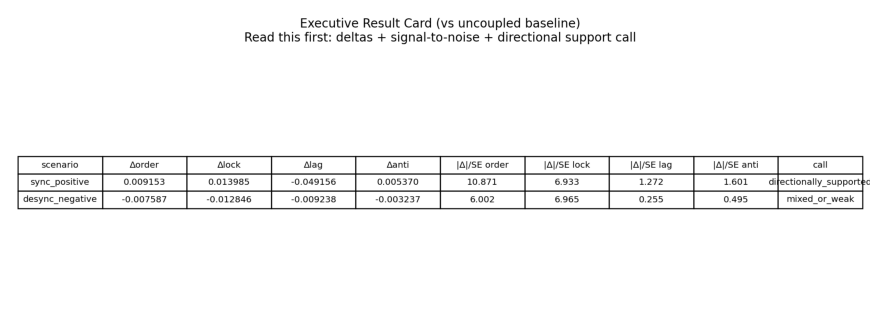

In [25]:
card_csv = GALLERY_V2 / "demo_executive_result_card.csv"
card_png = GALLERY_V2 / "demo_executive_result_card.png"

if card_csv.exists():
    display(pd.read_csv(card_csv))
else:
    print("Missing:", card_csv)

if card_png.exists():
    plt.figure(figsize=(14, 4))
    plt.imshow(mpimg.imread(card_png))
    plt.axis("off")
    plt.show()
else:
    print("Missing:", card_png)


## Reading Guide: Cross-Scenario Story Figures (Read These First)

- **Step 1: Effect-size + uncertainty** (`demo_effect_deltas_vs_uncoupled.png`). Read sign and CI before raw traces.
- **Step 2: Smoothed overlays** (`demo_sync_overlay_smoothed.png`). Look for persistent separation vs ribbon overlap.
- **Step 3: Mechanistic sanity** (`demo_crosscorr_hist_by_scenario.png`, `demo_phase_offset_small_multiples.png`). These connect coupling sign to pairwise phase relations.
- **Step 4: Failure mode** (`demo_failure_mode_boundary.png`). This teaches boundary ambiguity and classifier sensitivity.

Falsification check: if positive and negative coupling do not separate in deltas *and* mechanistic histograms, the demo story is too weak.


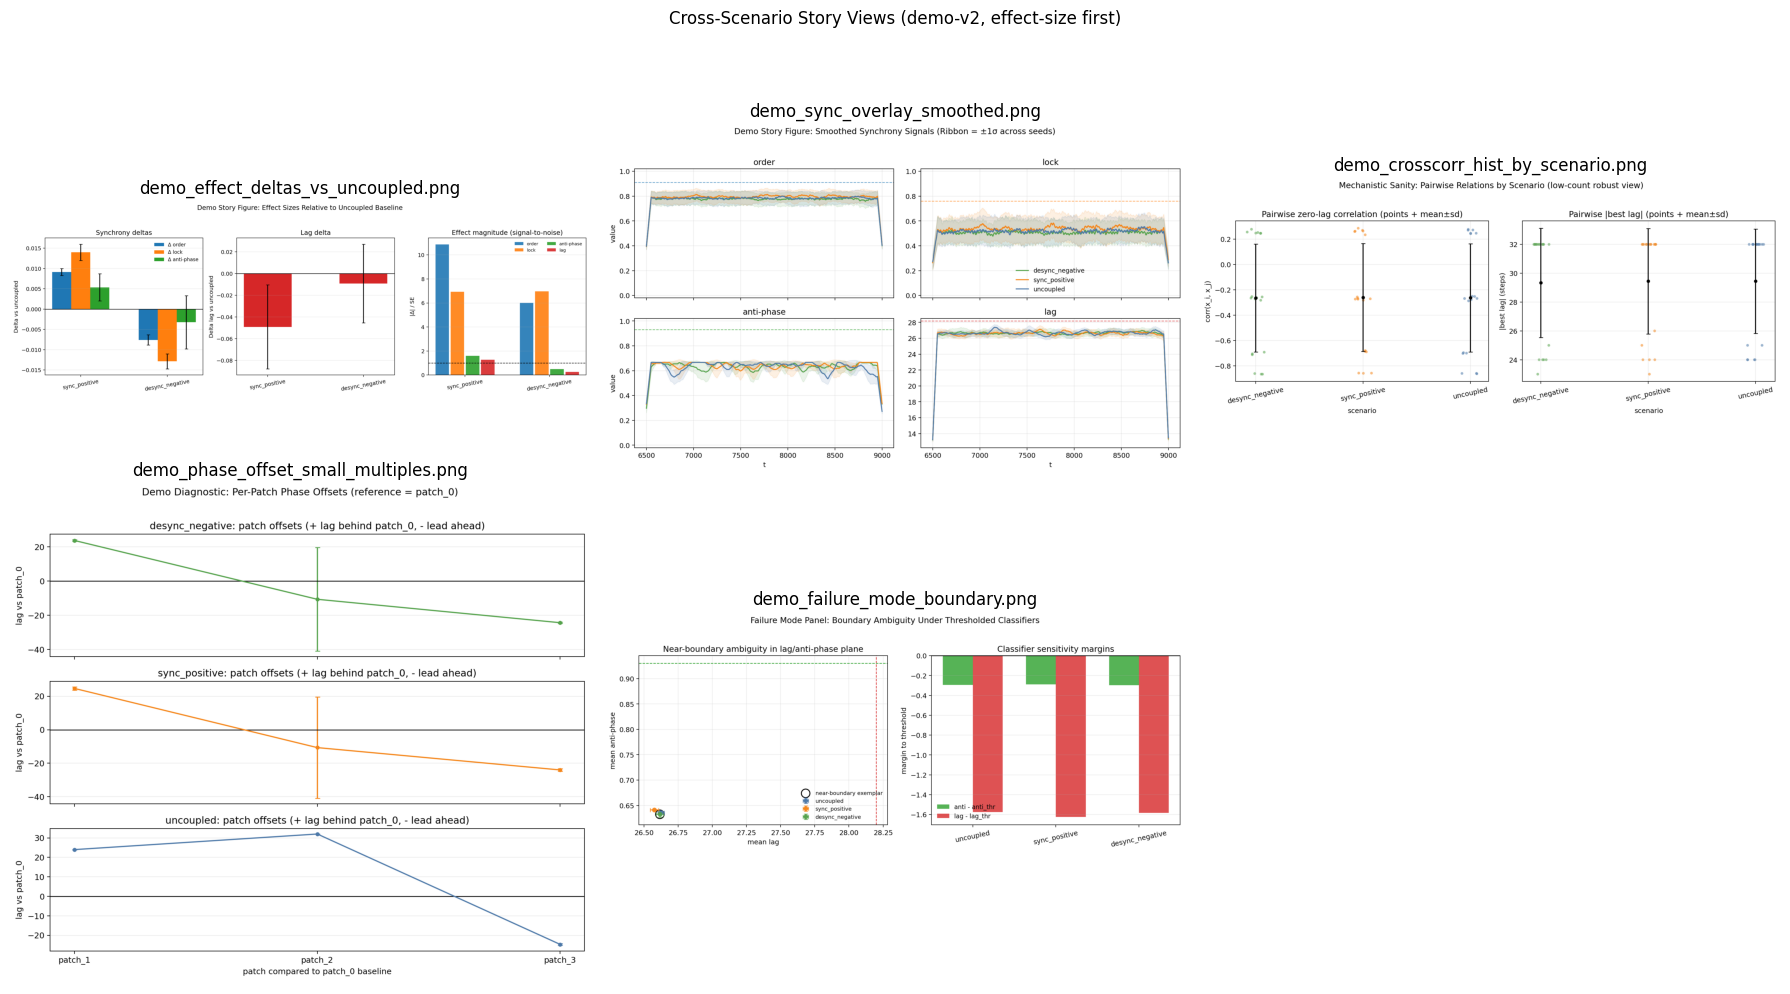

In [26]:
if "index" in gallery_v2:
    fig_paths = [
        GALLERY_V2 / "demo_effect_deltas_vs_uncoupled.png",
        GALLERY_V2 / "demo_sync_overlay_smoothed.png",
        GALLERY_V2 / "demo_crosscorr_hist_by_scenario.png",
        GALLERY_V2 / "demo_phase_offset_small_multiples.png",
        GALLERY_V2 / "demo_failure_mode_boundary.png",
    ]
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    for ax, p in zip(axes, fig_paths):
        if p.exists():
            ax.imshow(mpimg.imread(p))
            ax.set_title(p.name)
        else:
            ax.text(0.5, 0.5, f"Missing: {p.name}", ha="center", va="center")
        ax.axis("off")

    for ax in axes[len(fig_paths):]:
        ax.axis("off")

    fig.suptitle("Cross-Scenario Story Views (demo-v2, effect-size first)", y=0.99)
    fig.tight_layout()
    plt.show()


In [27]:
if "index" in gallery_v2:
    v2 = gallery_v2["index"].copy()
    num_cols = [
        "sync_order_mean",
        "sync_order_mean_seed_std",
        "sync_lock_mean",
        "sync_lock_mean_seed_std",
        "sync_lag_mean",
        "sync_lag_mean_seed_std",
        "sync_antiphase_mean",
        "sync_antiphase_mean_seed_std",
    ]
    for c in num_cols:
        if c in v2.columns:
            v2[c] = pd.to_numeric(v2[c], errors="coerce")

    base = v2.loc[v2["scenario_id"].str.contains("multipatch_uncoupled")].iloc[0]
    compare = v2[v2["scenario_id"].str.contains("multipatch_") & ~v2["scenario_id"].str.contains("uncoupled")].copy()

    compare["delta_order_vs_uncoupled"] = compare["sync_order_mean"] - base["sync_order_mean"]
    compare["delta_lock_vs_uncoupled"] = compare["sync_lock_mean"] - base["sync_lock_mean"]
    compare["delta_lag_vs_uncoupled"] = compare["sync_lag_mean"] - base["sync_lag_mean"]
    compare["delta_antiphase_vs_uncoupled"] = compare["sync_antiphase_mean"] - base["sync_antiphase_mean"]

    display(compare[[
        "scenario_id",
        "n_replicates",
        "replicate_seeds",
        "delta_order_vs_uncoupled",
        "delta_lock_vs_uncoupled",
        "delta_lag_vs_uncoupled",
        "delta_antiphase_vs_uncoupled",
    ]])

,scenario_id,n_replicates,replicate_seeds,delta_order_vs_uncoupled,delta_lock_vs_uncoupled,delta_lag_vs_uncoupled,delta_antiphase_vs_uncoupled
2,v2_multipatch_sync_positive,3,"111,222,333",0.009153,0.013985,-0.049156,0.005370
3,v2_multipatch_desync_negative,3,"111,222,333",-0.007587,-0.012846,-0.009238,-0.003237


## Reading Guide: Scenario Gallery Figure (Use After Story Figures)

- **What to look for:** scenario-level means and ribbons (`±1σ`), not high-frequency wiggles.
- **Diagnostics included in each panel:** consistent metric colors and threshold guides; burn-in shading appears only when informative in-window.
- **Interpretation:** use this view to inspect trajectories *after* effect-size and mechanism checks pass.


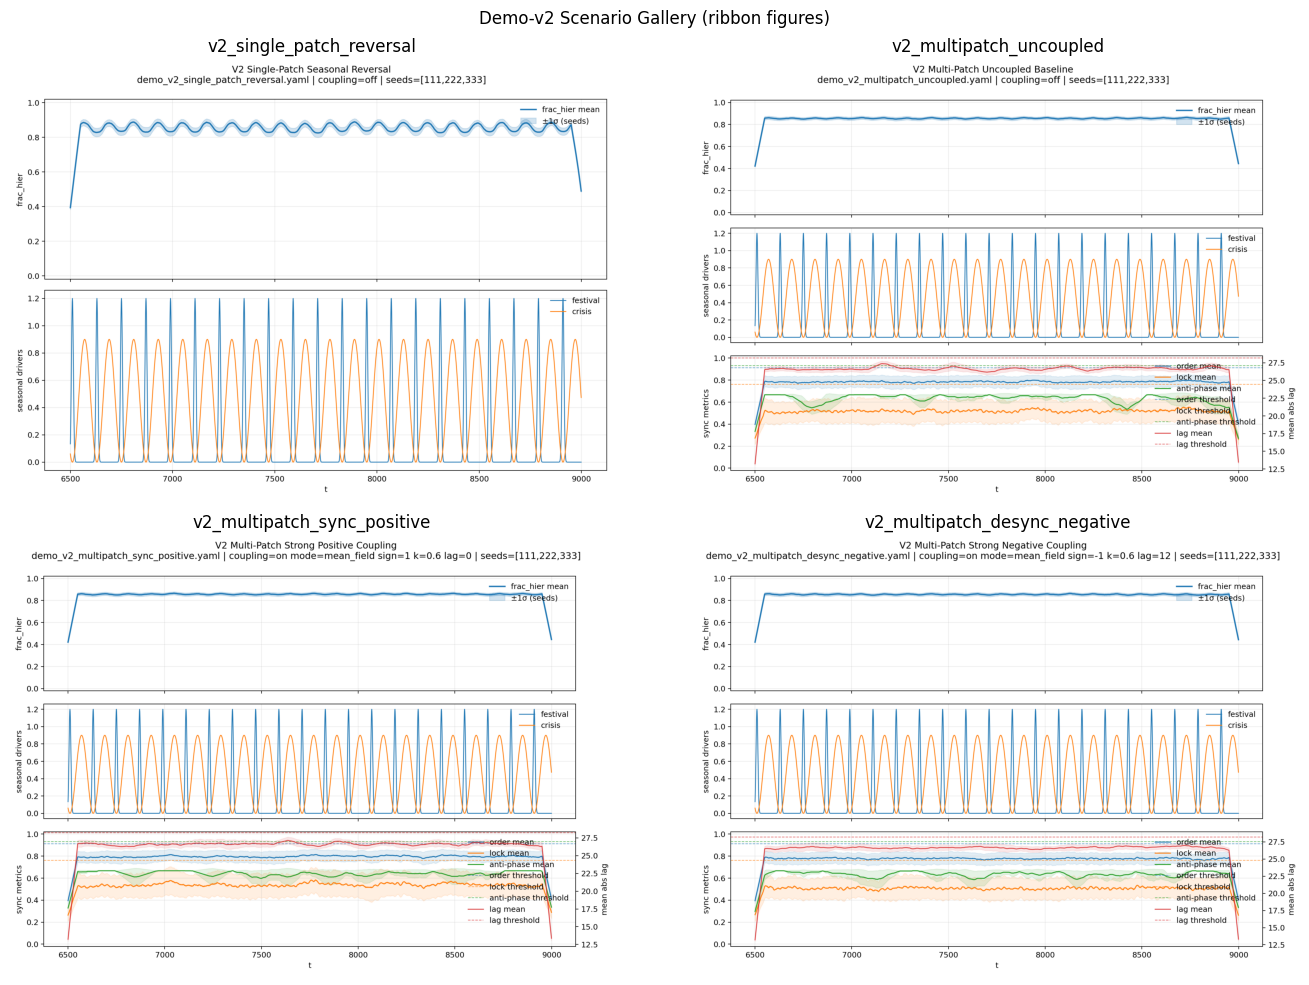

In [28]:
if "index" in gallery_v2:
    gdf = gallery_v2["index"].copy()
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for ax, (_, row) in zip(axes, gdf.iterrows()):
        img = mpimg.imread(row["figure_path"])
        ax.imshow(img)
        ax.set_title(row["scenario_id"])
        ax.axis("off")

    for ax in axes[len(gdf):]:
        ax.axis("off")

    fig.suptitle("Demo-v2 Scenario Gallery (ribbon figures)", y=0.98)
    fig.tight_layout()
    plt.show()
else:
    print("Run demo_v2 first to render this section.")

## Deep Dive: v2 Negative Coupling (One Replicate)

This cell inspects one replicate from `v2_multipatch_desync_negative` to connect
config knobs to emitted synchrony metrics.

## Reading Guide: Deep-Dive Replicate Figure

- **Top panel:** inspect patch trajectories for persistent offsets, not just high-frequency noise.
- **Bottom panel:** compare order/lock/anti-phase traces against threshold lines; lag on right axis determines strict v1 desync crossing.
- **Falsification check:** if threshold crossings are isolated spikes rather than sustained epochs, classify as near-boundary rather than robust regime evidence.


Coupling block:
{
  "enabled": true,
  "mode": "mean_field",
  "topology": "ring",
  "strength": 0.6,
  "sign": -1,
  "lag_steps": 12,
  "normalize_by_degree": true,
  "target_metric": "frac_hier"
}


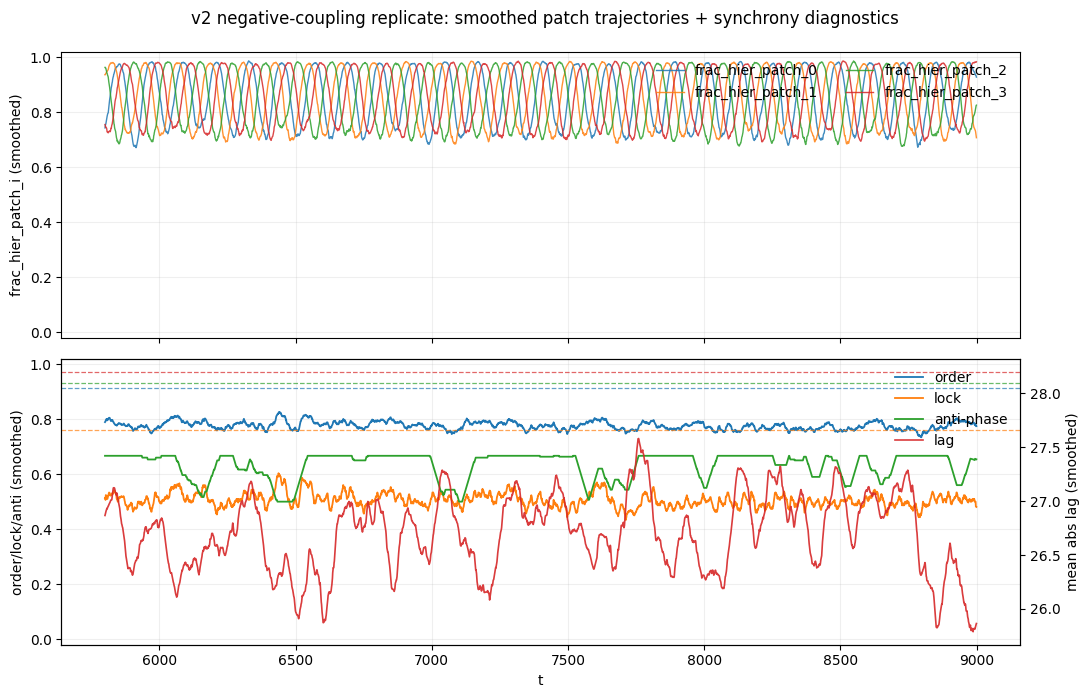

In [29]:
if "replicates" in gallery_v2:
    reps = gallery_v2["replicates"].copy()
    row = reps.loc[reps["scenario_id"] == "v2_multipatch_desync_negative"].iloc[0]
    config_path = Path(row["config_path"])
    metrics_path = Path(row["metrics_path"])

    cfg = yaml.safe_load(config_path.read_text(encoding="utf-8"))
    burn_in = int(cfg.get("runtime_and_reproducibility", {}).get("burn_in_period", 0))
    print("Coupling block:")
    print(json.dumps(cfg["inter_patch_coupling"], indent=2))

    thresholds_path = ROOT / "experiments" / "configs" / "phase3" / "desync_v2_thresholds.yaml"
    thresholds = yaml.safe_load(thresholds_path.read_text(encoding="utf-8")) if thresholds_path.exists() else {}

    colors = {
        "order": "tab:blue",
        "lock": "tab:orange",
        "anti": "tab:green",
        "lag": "tab:red",
    }

    m = pd.read_csv(metrics_path)
    m_tail = m.tail(3200).copy()
    t = m_tail["t"].to_numpy()
    patch_cols = [c for c in m_tail.columns if c.startswith("frac_hier_patch_")]

    def smooth(s, w):
        return s.rolling(window=w, min_periods=1, center=True).mean()

    for c in patch_cols:
        m_tail[f"{c}_sm"] = smooth(m_tail[c], 25)

    m_tail["order_sm"] = smooth(m_tail["synchrony_order_parameter"], 50)
    m_tail["lock_sm"] = smooth(m_tail["synchrony_phase_lock_fraction"], 50)
    m_tail["anti_sm"] = smooth(m_tail["synchrony_antiphase_fraction"], 50)
    m_tail["lag_sm"] = smooth(m_tail["synchrony_mean_abs_phase_lag"], 50)

    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
    for c in patch_cols:
        axes[0].plot(m_tail["t"], m_tail[f"{c}_sm"], linewidth=1.0, alpha=0.85, label=c)
    axes[0].set_ylabel("frac_hier_patch_i (smoothed)")
    axes[0].set_ylim(-0.02, 1.02)
    axes[0].legend(loc="upper right", ncol=2, frameon=False)
    axes[0].grid(alpha=0.2)

    axes[1].plot(m_tail["t"], m_tail["order_sm"], label="order", linewidth=1.3, color=colors["order"])
    axes[1].plot(m_tail["t"], m_tail["lock_sm"], label="lock", linewidth=1.3, color=colors["lock"])
    axes[1].plot(m_tail["t"], m_tail["anti_sm"], label="anti-phase", linewidth=1.3, color=colors["anti"])
    axes[1].set_ylabel("order/lock/anti (smoothed)")
    axes[1].set_ylim(-0.02, 1.02)
    axes[1].grid(alpha=0.2)

    ax2 = axes[1].twinx()
    ax2.plot(m_tail["t"], m_tail["lag_sm"], color=colors["lag"], alpha=0.9, linewidth=1.2, label="lag")
    ax2.set_ylabel("mean abs lag (smoothed)")

    if thresholds:
        if "desync_order_lo" in thresholds:
            axes[1].axhline(float(thresholds["desync_order_lo"]), color=colors["order"], linestyle="--", linewidth=0.9, alpha=0.7)
        if "desync_lock_lo" in thresholds:
            axes[1].axhline(float(thresholds["desync_lock_lo"]), color=colors["lock"], linestyle="--", linewidth=0.9, alpha=0.7)
        if "desync_antiphase_lo" in thresholds:
            axes[1].axhline(float(thresholds["desync_antiphase_lo"]), color=colors["anti"], linestyle="--", linewidth=0.9, alpha=0.7)
        if "desync_lag_lo" in thresholds:
            ax2.axhline(float(thresholds["desync_lag_lo"]), color=colors["lag"], linestyle="--", linewidth=0.9, alpha=0.7)

    if t.min() < burn_in < t.max() and (burn_in - t.min()) / max(1e-9, (t.max() - t.min())) >= 0.05:
        for ax in axes:
            ax.axvspan(t.min(), burn_in, color="gray", alpha=0.10)

    handles, labels = axes[1].get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    axes[1].legend(handles + h2, labels + l2, loc="upper right", frameon=False)

    axes[1].set_xlabel("t")
    fig.suptitle("v2 negative-coupling replicate: smoothed patch trajectories + synchrony diagnostics", y=0.99)
    fig.tight_layout()
    plt.show()


## Story To Tell

- `demo` pack: quick baseline orientation.
- `demo_v2` pack: stronger contrasts and 3-seed ribbons to reduce single-seed noise.
- Focus on *delta vs uncoupled* and ribbon overlap, not just raw trace complexity.

For claim-making, continue using phase manifests and governance notes; this notebook is for explanation and teaching.